# Chapter 9 — Files and Exceptions

## Objectives

In this chapter, you’ll:

- Understand the concepts of **files** and **persistent data**.  
- Learn how to **read**, **write**, and **update** files.  
- Work with **CSV files**, a common data format in machine learning.  
- **Serialize and deserialize** objects using **JSON**, a key data-interchange format for the web.  
- Use the **`with` statement** to ensure resources are properly released and avoid resource leaks.  
- Handle runtime errors using **`try`** and **`except`** blocks.  
- Use the **`else`** clause in a `try` statement to run code when no exceptions occur.  
- Use the **`finally`** clause to execute cleanup code, regardless of exceptions.  
- **Raise exceptions** manually to signal runtime issues.  
- Interpret **tracebacks** to understand where and why exceptions occur.  
- Use **pandas** to load and analyze data from the **Titanic Disaster dataset** (CSV format).

# 9.1 Introduction

Python variables, lists, tuples, dictionaries, sets, arrays, pandas Series, and DataFrames offer **temporary data storage**. The data they hold is lost when:

- A local variable goes out of scope, or  
- The program terminates.

To ensure **long-term data retention**, we use **files**. Files allow data persistence even after the program ends. These files are typically stored on **secondary storage devices** such as SSDs and hard drives.

This chapter covers:

- Creating, updating, and processing **data files** in Python  
- Working with common file formats like **text, JSON, and CSV**
- Using **JSON** for serialization/deserialization (saving and restoring objects)
- Using the **csv** module and **pandas** for reading and manipulating CSV data  
- Example dataset: **Titanic disaster dataset**

We also introduce:

- **Exception Handling** using `try`, `except`, `else`, and `finally`
- Writing **robust and fault-tolerant programs**
- Safe resource management using the **with statement**

Finally, we discuss **security risks** of using the `pickle` module for serialization and recommend **JSON** instead.

In [2]:
# Example: Writing and reading text files in Python

# Writing to a text file
with open("example.txt", "w") as file:
    file.write("Hello, world!\n")
    file.write("Python file handling demo.")

In [3]:
# Reading from a text file
with open("example.txt", "r") as file:
    contents = file.read()

print(contents)

Hello, world!
Python file handling demo.


In [4]:
# Example: Using JSON for serialization and deserialization

import json

data = {
    "name": "Alice",
    "age": 30,
    "skills": ["Python", "Data Analysis", "Machine Learning"]
}

In [5]:
# Serialize (write to file)
with open("data.json", "w") as file:
    json.dump(data, file)

In [6]:
# Deserialize (read from file)
with open("data.json", "r") as file:
    loaded_data = json.load(file)

print(loaded_data)

{'name': 'Alice', 'age': 30, 'skills': ['Python', 'Data Analysis', 'Machine Learning']}


In [9]:
# Example: Exception handling in Python

try:
    num = int(input("Enter a number: "))
    print(10 / num)
except ZeroDivisionError:
    print("Cannot divide by zero.")
except ValueError:
    print("Invalid input. Please enter a number.")
else:
    print("Division successful.")
finally:
    print("Operation complete.")


Enter a number: 4
2.5
Division successful.
Operation complete.


In [10]:
# Example: Using 'with' statement for safe resource management

# The 'with' statement ensures the file is closed even if an exception occurs
with open("safe_example.txt", "w") as file:
    file.write("This file will be closed automatically.")

print("File safely written and closed.")


File safely written and closed.


# 9.2 Files

Python views files as **sequences of characters** (for text files) or **sequences of bytes** (for binary files such as images or videos).

- The first character or byte in a file is at **position 0**.  
- In a file of `n` characters or bytes, the last position is `n - 1`.

Each file you open in Python creates a **file object**, which is used to interact with the file.

### End of File (EOF)
Different operating systems mark the end of a file differently. Some use an **end-of-file marker**, while others store a **byte count**.  
Python hides these low-level details from the programmer.

### Standard File Objects
When a Python program starts, it automatically creates three standard file objects:

| Object | Purpose | Default Behavior |
|---------|----------|------------------|
| `sys.stdin` | Standard input | Reads from keyboard |
| `sys.stdout` | Standard output | Prints to console |
| `sys.stderr` | Standard error | Displays errors and tracebacks |

These objects behave like files but are connected to the console.  
You can explicitly reference them by importing the `sys` module.

# 9.3 Text-File Processing

Python imposes **no structure** on files; you define the structure as needed.

We’ll create a simple **text file** to represent client accounts in an accounts-receivable system.  
Each record will contain:

- Account number  
- Last name  
- Account balance  

Each record will be stored **on a separate line**, ending with a newline (`\n`).


In [26]:
# Example: Writing to a text file using 'with' statement

with open('accounts.txt', mode='w') as accounts:
    accounts.write('100 Jones 24.98\n')
    accounts.write('200 Doe 345.67\n')
    accounts.write('300 White 0.00\n')
    accounts.write('400 Stone -42.16\n')
    accounts.write('500 Rich 224.62\n')


In [20]:
# Example: Writing to a file using print() (adds newline automatically)

with open('accounts_alt.txt', mode='w') as accounts:
    print('100 Jones 24.98', file=accounts)
    print('200 Doe 345.67', file=accounts)
    print('300 White 0.00', file=accounts)


### The `with` Statement

The `with` statement ensures **safe resource management**:

1. Acquires the resource (e.g., opens a file).  
2. Assigns it to a variable (`accounts` in this case).  
3. Automatically releases the resource (closes the file) when done — even if an exception occurs.

### Built-in Function `open`

Syntax:
```python
open(filename, mode)


| Mode   | Meaning                                             |
| ------ | --------------------------------------------------- |
| `'r'`  | Read (default)                                      |
| `'w'`  | Write (creates new file or overwrites existing one) |
| `'a'`  | Append (adds new data to end of file)               |
| `'r+'` | Read and write                                      |


### 9.3.2 Reading Data from a Text File

We just created the text file **`accounts.txt`** and wrote data to it.  
Now let’s read that data sequentially from beginning to end.

In [27]:
with open('accounts.txt', mode='r') as accounts: 
    print(f'{"Account":<10}{"Name":<10}{"Balance":>10}') 
    for record in accounts: 
        account, name, balance = record.split() 
        print(f'{account:<10}{name:<10}{balance:>10}') 

Account   Name         Balance
100       Jones          24.98
200       Doe           345.67
300       White           0.00
400       Stone         -42.16
500       Rich          224.62


### 9.4 Updating Text Files

Formatted data in a text file cannot be modified directly without risking corruption of other data, since text files store variable-length fields. To update a record safely, you can:

1. Copy all records **before** the target record into a temporary file.  
2. Write the **updated record** into the temporary file.  
3. Copy the remaining records **after** the target record.  
4. Delete the old file.  
5. Rename the temporary file to the original name.

This ensures data integrity even when fields vary in size.


In [30]:
# Updating 'accounts.txt' by changing 'White' to 'Williams'

accounts = open('accounts.txt', 'r')
temp_file = open('temp_file.txt', 'w')

with accounts, temp_file:
    for record in accounts:
        account, name, balance = record.split()
        if account != '300':
            temp_file.write(record)
        else:
            new_record = ' '.join([account, 'Williams', balance])
            temp_file.write(new_record + '\n')


In [32]:
# Reading from a text file
with open("temp_file.txt", "r") as file:
    contents = file.read()

print(contents)

100 Jones 24.98
200 Doe 345.67
300 Williams 0.00
400 Stone -42.16
500 Rich 224.62



In [33]:
# Using os module to replace the old file with the updated one

import os

os.remove('accounts.txt')                 # Delete old file
os.rename('temp_file.txt', 'accounts.txt')  # Rename temp file


> ⚠️ Note: Use `os.remove()` carefully — it permanently deletes the specified file.


### 9.5 Serialization with JSON

**JSON (JavaScript Object Notation)** is a text-based, human- and machine-readable format used for data interchange.  
It represents data as **key–value pairs** similar to Python dictionaries.

JSON is widely used for:
- Communicating with web APIs (e.g., Twitter, IBM Watson)
- Storing structured data (e.g., configuration, datasets)
- Transmitting objects across platforms  

Python provides the built-in **`json`** module to handle serialization (converting Python objects to JSON) and deserialization (reading JSON into Python objects).


In [35]:
# Example Python dictionary
accounts_dict = {
    'accounts': [
        {'account': 100, 'name': 'Jones', 'balance': 24.98},
        {'account': 200, 'name': 'Doe', 'balance': 345.67}
    ]
}

accounts_dict

{'accounts': [{'account': 100, 'name': 'Jones', 'balance': 24.98},
  {'account': 200, 'name': 'Doe', 'balance': 345.67}]}

#### Serializing to JSON
To write a Python object into a JSON file, use the `json.dump()` function.


In [36]:
import json

with open('accounts.json', 'w') as accounts:
    json.dump(accounts_dict, accounts)


This creates a file named **`accounts.json`** containing:

```json
{"accounts": [
    {"account": 100, "name": "Jones", "balance": 24.98},
    {"account": 200, "name": "Doe", "balance": 345.67}
]}


#### Deserializing from JSON
To read a JSON file and convert it back into a Python object, use the `json.load()` function.


In [37]:
with open('accounts.json', 'r') as accounts:
    accounts_json = json.load(accounts)

accounts_json


{'accounts': [{'account': 100, 'name': 'Jones', 'balance': 24.98},
  {'account': 200, 'name': 'Doe', 'balance': 345.67}]}

You can access the data as normal Python dictionaries and lists:


In [38]:
accounts_json['accounts'][0]  # First account
accounts_json['accounts'][1]  # Second account

{'account': 200, 'name': 'Doe', 'balance': 345.67}

#### Pretty Printing JSON
Use `json.dumps()` (short for “dump string”) to return a JSON-formatted string.  
Add the `indent` argument to format it neatly for display.


In [45]:
with open('accounts.json', 'r') as accounts:
    print(json.dumps(json.load(accounts), indent=4))

{
    "accounts": [
        {
            "account": 100,
            "name": "Jones",
            "balance": 24.98
        },
        {
            "account": 200,
            "name": "Doe",
            "balance": 345.67
        }
    ]
}


## 9.6 Focus on Security: `pickle` Serialization and Deserialization

The Python Standard Library’s `pickle` module can serialize objects into a **Python-specific data format**. However, it comes with **serious security warnings**.

>  **Warning from Python Documentation:**
> 
> “Pickle files can be hacked. If you receive a raw pickle file over the network, don’t trust it!  
> It could contain malicious code that executes arbitrary Python commands when you try to unpickle it.  
> However, if you are doing your own pickle writing and reading, you’re safe (provided no one else has access to the pickle file).”

> “Pickle is a protocol that allows serialization of arbitrarily complex Python objects.  
> As such, it is **specific to Python** and **cannot be used to communicate with applications written in other languages**.  
> It is also **insecure by default**: deserializing pickle data from an untrusted source can execute arbitrary code.”

Because of these security risks, **using `pickle` is not recommended**.  
However, you may still encounter it in **legacy Python code** that was written before modern, safer alternatives (like `json`) became common.

In [46]:
# Example: (For educational purposes only — do NOT use pickle with untrusted data)
import pickle

# A sample Python object
data = {'name': 'Alice', 'balance': 250.75, 'active': True}

# Serialize (pickle) the object to a file
with open('data.pkl', 'wb') as file:
    pickle.dump(data, file)

# Deserialize (unpickle) the object from the file
with open('data.pkl', 'rb') as file:
    loaded_data = pickle.load(file)

print(loaded_data)


{'name': 'Alice', 'balance': 250.75, 'active': True}


## 9.7 Additional Notes Regarding Files

The following table summarizes **file-open modes** for **text files**, including those for reading and writing.  
- The **write (`'w'`)** and **append (`'a'`)** modes create a file if it does not exist.  
- The **read (`'r'`)** mode raises a `FileNotFoundError` if the file does not exist.  
- Each text-file mode has a **corresponding binary mode**, denoted by adding `'b'` (e.g., `'rb'`, `'wb+'`).  
  Binary modes are used for non-text data such as **images, audio, video, ZIP files**, and other custom binary formats.


| Mode   | Description |
| ------- | ------------ |
| `'r'`   | Read text file (file must exist) |
| `'w'`   | Write text file (creates new file or overwrites existing one) |
| `'a'`   | Append to text file (creates if not existing) |
| `'r+'`  | Read and write text file |
| `'w+'`  | Write and read text file (overwrites if existing) |
| `'a+'`  | Append and read text file (creates if not existing) |
| `'rb'`  | Read binary file |
| `'wb'`  | Write binary file |
| `'ab'`  | Append binary file |
| `'rb+'` | Read and write binary file |
| `'wb+'` | Write and read binary file |
| `'ab+'` | Append and read binary file |


### Other File Object Methods

Here are a few additional useful methods for working with file objects:

- **`read([size])`**  
  Reads and returns up to `size` characters (text mode) or bytes (binary mode).  
  If no argument is given, it reads the entire file.

- **`readline()`**  
  Reads and returns one line of text, including the newline character `\n` if present.  
  Returns an empty string when the end of file is reached.

- **`writelines(list_of_strings)`**  
  Writes each string in the provided list to the file (does not automatically add newline characters).

The classes used by Python to create and manage file objects are defined in the **`io` module** of the Python Standard Library. 

In [48]:
# Example: Demonstrating file object methods
# Writing multiple lines to a file
lines = ["Line 1\n", "Line 2\n", "Line 3\n"]
with open("example.txt", "w") as f:
    f.writelines(lines)

In [49]:
# Reading contents
with open("example.txt", "r") as f:
    print("Reading entire file:")
    print(f.read())

Reading entire file:
Line 1
Line 2
Line 3



In [50]:
# Reading line by line
with open("example.txt", "r") as f:
    print("\nReading one line at a time:")
    print(f.readline(), end="")
    print(f.readline(), end="")


Reading one line at a time:
Line 1
Line 2


## 9.8 Handling Exceptions

Various types of exceptions can occur while working with files and user inputs:

- **`FileNotFoundError`** — occurs when trying to open a non-existent file in `'r'` or `'r+'` mode.  
- **`PermissionError`** — occurs when attempting to access or create a file without the necessary permissions.  
- **`ValueError`** — occurs when performing an invalid I/O operation, such as writing to a closed file.


### 9.8.1 Division by Zero and Invalid Input

#### Division by Zero
A `ZeroDivisionError` occurs when attempting to divide by zero:

In [52]:
10 / 0

ZeroDivisionError: division by zero

#### Invalid Input
A `ValueError` occurs when trying to convert a non-numeric string to an integer:

In [53]:
value = int(input('Enter an integer: '))

Enter an integer: hello


ValueError: invalid literal for int() with base 10: 'hello'

In [54]:
"""Simple exception handling example."""

while True:
    try:
        number1 = int(input('Enter numerator: '))
        number2 = int(input('Enter denominator: '))
        result = number1 / number2
    except ValueError:
        print('You must enter two integers\n')
    except ZeroDivisionError:
        print('Attempted to divide by zero\n')
    else:
        print(f'{number1:.3f} / {number2:.3f} = {result:.3f}')
        break


Enter numerator: 2
Enter denominator: 0
Attempted to divide by zero

Enter numerator: 5
Enter denominator: 8
5.000 / 8.000 = 0.625


### try Clause
The **`try`** block encloses code that might raise an exception.

### except Clause
Each **`except`** clause specifies the type of exception to handle.
- Handles `ValueError` when conversion to integer fails.
- Handles `ZeroDivisionError` when division by zero occurs.

### else Clause
The **`else`** block executes only when no exceptions occur.  
Here, it prints the result and terminates the loop.


### Flow of Control

#### For a `ZeroDivisionError`
1. User enters valid numerator (e.g., `100`).
2. User enters `0` as denominator.
3. Division raises a `ZeroDivisionError`.
4. Control transfers to the corresponding `except` handler.
5. The message `"Attempted to divide by zero"` is displayed.
6. Program continues with the next loop iteration.

#### For a `ValueError`
1. User enters valid numerator (e.g., `100`).
2. User enters invalid denominator (e.g., `hello`).
3. Conversion raises a `ValueError`.
4. The `except ValueError` handler executes.
5. The message `"You must enter two integers"` is displayed.
6. Program continues with the next loop iteration.

#### For a Successful Division
1. User enters valid integers for both numerator and denominator.
2. No exceptions are raised.
3. The **`else`** clause executes, displaying the result.
4. The loop terminates successfully.

## 9.8.3 Catching Multiple Exceptions in One except Clause

If multiple exception types require the same handling, they can be grouped into one `except` clause using a tuple:

```python
except (Type1, Type2, ...) as variable_name:


The `as` clause is optional. If provided, it allows access to the caught exception object. This is useful when you need to inspect or log the specific exception details.

In [58]:
try:
    number = int(input("Enter a number: "))
    result = 10 / number
except (ValueError, ZeroDivisionError) as error:
    print(f"An error occurred: {error}")
else:
    print(f"Result: {result}")


Enter a number: 0
An error occurred: division by zero


## 9.8.4 Determining What Exceptions a Function or Method Raises

Exceptions can occur:
- Directly in a `try` suite,
- Indirectly through functions or methods called within it,
- Or via the interpreter during code execution (for example, `ZeroDivisionError`).

**Best practice:**  
Always review a function or method’s API documentation to identify possible exceptions and understand why they occur. This helps write robust code with appropriate exception handling.


## 9.8.5 What Code Should Be Placed in a try Suite?

A `try` suite should enclose a *logical section* of code where exceptions might occur — not every single line individually.

Guidelines:
- Enclose related operations that may raise exceptions together.
- Keep the suite small enough to clearly understand the context of an exception.
- Use multiple `try` statements if you need to distinguish between different contexts.


## 9.9 The finally Clause

Operating systems often prevent simultaneous access to a file by multiple programs.  
When a program finishes processing a file, it should **close it** to release system resources and prevent *resource leaks*.


### finally Clause in a try Statement

The `finally` clause executes **regardless** of whether:
- the `try` suite runs successfully, or
- an exception occurs.

This makes it ideal for resource deallocation or cleanup tasks (e.g., closing files, releasing locks).

> In Python, `with` statements are preferred for managing resources, while `finally` is used for other cleanup tasks.


In [59]:
# Example 1: No exception raised
try:
    print('try suite with no exceptions raised')
except:
    print('this will not execute')
else:
    print('else executes because no exceptions in the try suite')
finally:
    print('finally always executes')


try suite with no exceptions raised
else executes because no exceptions in the try suite
finally always executes


In [60]:
# Example 2: Exception raised
try:
    print('try suite that raises an exception')
    int('hello')  # Raises ValueError
    print('this will not execute')
except ValueError:
    print('a ValueError occurred')
else:
    print('else will not execute because an exception occurred')
finally:
    print('finally always executes')


try suite that raises an exception
a ValueError occurred
finally always executes


## Combining with `with` Statements and try…except

Resources like files, network sockets, or database connections can raise exceptions.  
A robust approach is to use a `with` statement **inside a try suite**, which:
- Ensures automatic resource release,
- Allows exception handling via `except` blocks,
- Eliminates the need for a `finally` clause.


In [61]:
try:
    with open('gradez.txt', 'r') as accounts:
        print(f'{"ID":<3}{"Name":<7}{"Grade"}')
        for record in accounts:
            student_id, name, grade = record.split()
            print(f'{student_id:<3}{name:<7}{grade}')
except FileNotFoundError:
    print('The file name you specified does not exist')


The file name you specified does not exist



This structure ensures that the file is automatically closed (even if an exception occurs),  
and the program gracefully handles missing or invalid files.


# 9.10 Explicitly Raising an Exception

Sometimes, you may want to **raise exceptions manually** to signal that an error condition has occurred in your code. This can help notify other parts of the program (or users) about invalid operations or unexpected states.

---

## Basic Syntax

```python
raise ExceptionClassName


In [62]:
raise ExceptionClassName("Custom error message")

NameError: name 'ExceptionClassName' is not defined

In [63]:
def divide(a, b):
    if b == 0:
        raise ZeroDivisionError("Cannot divide by zero!")
    return a / b

try:
    print(divide(10, 0))
except ZeroDivisionError as e:
    print("Error occurred:", e)


Error occurred: Cannot divide by zero!


In [64]:
def set_age(age):
    if age < 0:
        raise ValueError("Age cannot be negative.")
    print(f"Age set to {age}")

try:
    set_age(-3)
except ValueError as e:
    print("Invalid input:", e)


Invalid input: Age cannot be negative.


# 9.11 Stack Unwinding and Tracebacks

When an exception occurs in Python, the interpreter generates a **traceback** that shows the sequence of function calls leading to the error. This helps identify where the problem originated.

---

## Example: Functions and Traceback


In [65]:
def function1():
    function2()

def function2():
    raise Exception("An exception occurred")

function1()


Exception: An exception occurred

# 9.12 Intro to Data Science: Working with CSV Files

Throughout this book, you’ll work with many datasets as you learn data-science concepts. **CSV (comma-separated values)** is a particularly popular file format.  
In this section, we’ll demonstrate CSV file processing using the **Python Standard Library’s `csv` module** and **pandas**.

---

## 9.12.1 Python Standard Library Module `csv`

The `csv` module provides functions for working with CSV files.  
Documentation: [Python CSV module](https://docs.python.org/3/library/csv.html)


### Writing to a CSV File

Let’s create an `accounts.csv` file using CSV format.  
The `csv` module’s documentation recommends opening CSV files with the additional keyword argument `newline=''` to ensure that newlines are processed properly:


In [66]:
import csv

with open('accounts.csv', mode='w', newline='') as accounts:
    writer = csv.writer(accounts)
    writer.writerow([100, 'Jones', 24.98])
    writer.writerow([200, 'Doe', 345.67])
    writer.writerow([300, 'White', 0.00])
    writer.writerow([400, 'Stone', -42.16])
    writer.writerow([500, 'Rich', 224.62])


In [69]:
# Reading from a file
with open("accounts.csv", "r") as file:
    contents = file.read()

print(contents)

100,Jones,24.98
200,Doe,345.67
300,White,0.0
400,Stone,-42.16
500,Rich,224.62



The `.csv` file extension indicates a CSV-format file.  
The `csv.writer()` function returns an object that writes CSV data to the specified file object.  

Each call to the writer’s `writerow` method receives an iterable to store in the file. Here we’re using **lists**.  
By default, `writerow` delimits values with commas, but you can specify custom delimiters.



CSV files generally do not contain spaces after commas, but some people use them to enhance readability.

You can also write all records at once using `writerows()`.



### Quoting Strings with Commas

If you write data that contains commas within a string, `writerow` automatically encloses that string in double quotes.

For example:


In [68]:
with open('example.csv', mode='w', newline='') as example:
    writer = csv.writer(example)
    writer.writerow([100, 'Jones, Sue', 24.98])


In [72]:
# Reading from a file
with open("example.csv", "r") as file:
    contents = file.read()

print(contents)
# The quotes around `"Jones, Sue"` indicate that this is a single value.

100,"Jones, Sue",24.98



### Reading from a CSV File

Now let’s read the CSV data from `accounts.csv`.  
The following snippet reads and displays each record:


In [73]:
with open('accounts.csv', 'r', newline='') as accounts:
    print(f'{"Account":<10}{"Name":<10}{"Balance":>10}')
    reader = csv.reader(accounts)

    for record in reader:
        account, name, balance = record
        print(f'{account:<10}{name:<10}{balance:>10}')


Account   Name         Balance
100       Jones          24.98
200       Doe           345.67
300       White            0.0
400       Stone         -42.16
500       Rich          224.62



The `csv.reader()` function reads CSV-format data from a file.  
You can iterate through it record by record — each record is returned as a list of values.


## Caution: Commas in CSV Data Fields

Be careful when working with strings containing embedded commas.

If you mistakenly enter `'Jones'` and `'Sue'` as two separate values instead of `'Jones, Sue'`,  
then `writerow` would create a CSV record with **four fields**, not three.

Example:


In [75]:
[100, 'Jones', 'Sue', 24.98]

[100, 'Jones', 'Sue', 24.98]

In [76]:
[200, 'Doe', 345.67]

[200, 'Doe', 345.67]

If you **omit a comma**:


In [78]:
100,85,77,9

(100, 85, 77, 9)

In [77]:
100,8577,9

(100, 8577, 9)

# 9.12.2 Reading CSV Files into Pandas DataFrames

In previous sections, we introduced many **pandas fundamentals**.  
Here, we’ll demonstrate pandas’ ability to **load CSV files** and perform **basic data analysis**.

---

## Datasets

In the data-science examples throughout this book, we’ll use various **free and open datasets** to demonstrate machine learning and natural language processing concepts.

Some useful dataset repositories include:

- **Rdatasets** (over 1100 datasets):  
  [https://vincentarelbundock.github.io/Rdatasets/datasets.html](https://vincentarelbundock.github.io/Rdatasets/datasets.html)
- **pydataset** module for accessing Rdatasets:  
  [https://github.com/iamaziz/PyDataset](https://github.com/iamaziz/PyDataset)
- **Awesome Public Datasets** collection:  
  [https://github.com/awesomedata/awesome-public-datasets](https://github.com/awesomedata/awesome-public-datasets)

A popular dataset for beginners is the **Titanic Disaster dataset**, which lists passengers and their survival status after the ship struck an iceberg in April 1912.


## Working with Locally Stored CSV Files

You can load a CSV dataset into a pandas DataFrame using the `pd.read_csv()` function.

Let’s load and display the `accounts.csv` file created earlier:


In [81]:
import pandas as pd

df = pd.read_csv('accounts.csv', names=['account', 'name', 'balance'])
df


,account,name,balance
0,100,Jones,24.98
1,200,Doe,345.67
2,300,White,0.00
3,400,Stone,-42.16
4,500,Rich,224.62


The `names` argument specifies the column names for the DataFrame.  
If omitted, `read_csv()` assumes the first row of the file contains column names.

### Saving a DataFrame to a CSV File

You can save a DataFrame to CSV using the `to_csv()` method:

In [82]:
df.to_csv('accounts_from_dataframe.csv', index=False)

The `index=False` argument omits row indices from the file.  

# 9.12.3 Reading the Titanic Disaster Dataset

The **Titanic dataset** is one of the most famous datasets for learning data analysis and machine learning.

We’ll demonstrate how to load it directly from a URL.


In [87]:
import pandas as pd

titanic = pd.read_csv(
    'https://vincentarelbundock.github.io/Rdatasets/csv/carData/TitanicSurvival.csv'
)

## Viewing Some of the Rows in the Titanic Dataset

The dataset contains over 1300 rows—one for each passenger.  
Let’s display the first and last five rows using `head()` and `tail()`.


In [90]:
titanic.head()

,rownames,survived,sex,age,passengerClass
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


In [91]:
titanic.tail()

,rownames,survived,sex,age,passengerClass
1304,"Zabour, Miss. Hileni",no,female,14.5,3rd
1305,"Zabour, Miss. Thamine",no,female,NaN,3rd
1306,"Zakarian, Mr. Mapriededer",no,male,26.5,3rd
1307,"Zakarian, Mr. Ortin",no,male,27.0,3rd
1308,"Zimmerman, Mr. Leo",no,male,29.0,3rd


## Customizing Column Names

The first column name (`Unnamed: 0`) isn’t very descriptive.  
Let’s rename it to `'name'` and shorten `'passengerClass'` to `'class'`.


In [92]:
titanic.columns = ['name', 'survived', 'sex', 'age', 'class']
titanic.head()

,name,survived,sex,age,class
0,"Allen, Miss. Elisabeth Walton",yes,female,29.0000,1st
1,"Allison, Master. Hudson Trevor",yes,male,0.9167,1st
2,"Allison, Miss. Helen Loraine",no,female,2.0000,1st
3,"Allison, Mr. Hudson Joshua Crei",no,male,30.0000,1st
4,"Allison, Mrs. Hudson J C (Bessi",no,female,25.0000,1st


# 9.12.4 Simple Data Analysis with the Titanic Dataset

We can now use pandas to perform simple descriptive statistics.

### Descriptive Statistics for Numeric Columns


In [93]:
titanic.describe()

,age
count,1046.000000
mean,29.881135
std,14.413500
min,0.166700
25%,21.000000
50%,28.000000
75%,39.000000
max,80.000000


Here, only the numeric column `age` is summarized:

- **count** — number of non-missing values (1046)
- **mean** — average age (29.88 years)
- **std** — standard deviation (14.41)
- **min/max** — youngest and oldest passengers
- **25%, 50%, 75%** — quartiles (percentiles)

Pandas automatically ignores missing (`NaN`) data during calculations.


### Descriptive Statistics for Categorical Columns

Let’s analyze the `survived` column:


In [94]:
(titanic.survived == 'yes').describe()

count      1309
unique        2
top       False
freq        809
Name: survived, dtype: object

For non-numeric (categorical) data:

- **count** — total number of entries  
- **unique** — number of unique values (2: True/False)  
- **top** — most frequent value  
- **freq** — frequency of that value  


# 9.12.5 Passenger Age Histogram

Visualization helps you understand your data more intuitively.  
Pandas provides built-in plotting powered by Matplotlib.

To enable Matplotlib in IPython or Jupyter:


In [95]:
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


Now let’s plot a **histogram** for the numerical data columns.


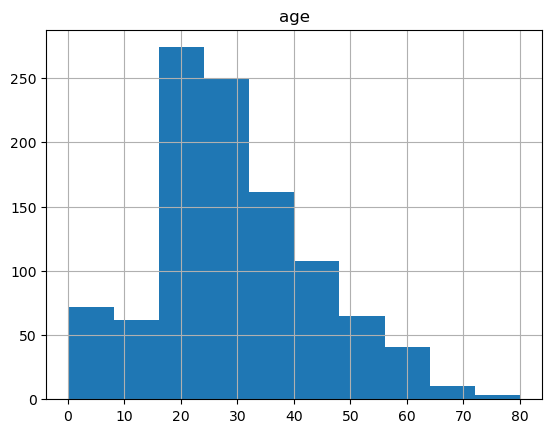

In [96]:
histogram = titanic.hist()

This dataset contains only one numeric column (`age`),  
so it produces a single histogram showing the **age distribution** of Titanic passengers.

For datasets with multiple numeric columns, `hist()` generates a separate plot for each.


# 9.13 Wrap-Up

In this chapter, we introduced **text-file processing** and **exception handling**. Files are used to store data persistently.  

We discussed **file objects** and mentioned that Python views a file as a sequence of **characters or bytes**. We also mentioned the **standard file objects** that are automatically created for you when a Python program begins executing.


## File Operations and Formats

We showed how to **create, read, write, and update text files**.  
We considered several popular file formats:

- **Plain text**
- **JSON (JavaScript Object Notation)**
- **CSV (Comma-Separated Values)**

We used the built-in `open` function and the `with` statement to:
- Open a file  
- Write to or read from the file  
- Automatically close the file to prevent resource leaks  

We also used the **Python Standard Library’s `json` module** to:
- Serialize objects into JSON format and store them in a file  
- Load JSON objects from a file  
- Deserialize them into Python objects  
- Pretty-print a JSON object for readability  

## Exception Handling

We discussed how **exceptions** indicate execution-time problems and listed the various exceptions you’ve already seen.  

We showed how to deal with exceptions by wrapping code in **`try` statements** that provide **`except` clauses** to handle specific types of exceptions that may occur in the `try` suite — making your programs more robust and fault-tolerant.

We also discussed the `try` statement’s **`finally` clause** for executing code if program flow entered the corresponding `try` suite.  

You can use either the `with` statement or a `try` statement’s `finally` clause for this purpose — we prefer the `with` statement.


## Intro to Data Science Recap

In the **Intro to Data Science** section, we used both:
- The Python Standard Library’s **`csv` module**, and  
- Capabilities of the **`pandas` library**  

to load, manipulate, and store CSV data.  

We loaded the **Titanic disaster dataset** into a `pandas` DataFrame, changed some column names for readability, displayed the head and tail of the dataset, and performed simple analysis of the data.
